# Entrenamiento de ConvNeXt-Tiny para clasificación binaria de tumores ováricos

Este notebook tiene como objetivo entrenar la arquitectura ConvNeXt-Tiny bajo el protocolo experimental definido para la clasificación automática de tumores ováricos benignos y malignos mediante imágenes ecográficas 2D.

Se emplea transferencia de aprendizaje utilizando pesos preentrenados y una función de pérdida ponderada para considerar el desbalance presente en el conjunto de datos.

## Configuración experimental

La configuración utilizada corresponde al baseline del benchmark de arquitecturas CNN.

In [1]:
from pathlib import Path
import sys
import torch
import torch.nn as nn

PROJECT_DIR = Path("../../../..").resolve()

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

print(PROJECT_DIR)

/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification


## Importación de componentes desarrollados

In [2]:
from src.classification.transforms import (
    get_classification_transforms
)

from src.classification.dataset import (
    MMOTUClassificationDataset
)

from src.classification.dataloader import (
    create_dataloader
)

from src.classification.models import (
    create_convnext_tiny_classifier
)

from src.classification.train import (
    train_model
)

from src.classification.utils import (
    compute_class_weights
)

## Configuración del dispositivo

Se utilizará aceleración mediante GPU CUDA cuando esté disponible.

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

device

device(type='cuda')

In [4]:
DATA_DIR = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "MMOTU_OTU_2D_experimental"
)


CSV_PATH = (
    PROJECT_DIR /
    "configs" /
    "splits" /
    "mmotu_experimental_split_standard.csv"
)

In [5]:
transform = get_classification_transforms()


train_dataset = MMOTUClassificationDataset(
    CSV_PATH,
    DATA_DIR,
    "train",
    transform
)


val_dataset = MMOTUClassificationDataset(
    CSV_PATH,
    DATA_DIR,
    "validation",
    transform
)


test_dataset = MMOTUClassificationDataset(
    CSV_PATH,
    DATA_DIR,
    "test",
    transform
)

In [6]:
train_loader = create_dataloader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = create_dataloader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = create_dataloader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [7]:
print("Train:", len(train_loader))
print("Validation:", len(val_loader))
print("Test:", len(test_loader))

Train: 25
Validation: 7
Test: 15


## Inicialización de la arquitectura DenseNet121

Se utiliza la arquitectura DenseNet121 mediante transferencia de aprendizaje.

In [8]:
model = create_convnext_tiny_classifier(
    pretrained=True,
    num_classes=2,
    freeze_backbone=False
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /home/jvillanueva/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:04<00:00, 23.9MB/s] 


In [9]:
print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=2, bias=True)
)


## Configuración de la función de pérdida

Debido al desbalance observado en el conjunto de entrenamiento, se emplea una función CrossEntropyLoss ponderada.

In [10]:
import pandas as pd


train_df = pd.read_csv(
    CSV_PATH
)


train_labels = (
    train_df[
        train_df["experimental_split"]=="train"
    ]["binary_label"]
    .values
)

In [11]:
class_weights = compute_class_weights(
    train_labels
)

print(class_weights)

tensor([0.5610, 4.5977])


In [12]:
class_weights = class_weights.to(device)

In [13]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

## Configuración del optimizador

Se utiliza AdamW como optimizador debido a su comportamiento estable en escenarios de transferencia de aprendizaje y ajuste fino de redes profundas.

Los hiperparámetros corresponden al protocolo experimental base definido para la comparación de arquitecturas.

In [14]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [15]:
MODEL_DIR = (
    PROJECT_DIR /
    "models" /
    "classification"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SAVE_PATH = (
    MODEL_DIR /
    "convnext_tiny_baseline_best.pth"
)

print(SAVE_PATH)

/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/models/classification/convnext_tiny_baseline_best.pth


In [16]:
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    save_path=SAVE_PATH
)

Epoch 1/30
Train Loss: 0.6854 | Train Acc: 0.6325
Val Loss: 0.6071 | Val Acc: 0.6300
Modelo guardado
Epoch 2/30
Train Loss: 0.4720 | Train Acc: 0.7550
Val Loss: 0.6090 | Val Acc: 0.7800
Epoch 3/30
Train Loss: 0.2608 | Train Acc: 0.9038
Val Loss: 0.5891 | Val Acc: 0.7500
Modelo guardado
Epoch 4/30
Train Loss: 0.1585 | Train Acc: 0.9275
Val Loss: 0.7369 | Val Acc: 0.7350
Epoch 5/30
Train Loss: 0.1791 | Train Acc: 0.9375
Val Loss: 0.6892 | Val Acc: 0.8850
Epoch 6/30
Train Loss: 0.0679 | Train Acc: 0.9788
Val Loss: 1.2498 | Val Acc: 0.9100
Epoch 7/30
Train Loss: 0.0166 | Train Acc: 0.9988
Val Loss: 1.4262 | Val Acc: 0.9000
Epoch 8/30
Train Loss: 0.0104 | Train Acc: 0.9975
Val Loss: 1.9408 | Val Acc: 0.9000
Epoch 9/30
Train Loss: 0.0053 | Train Acc: 0.9988
Val Loss: 1.8778 | Val Acc: 0.9000
Epoch 10/30
Train Loss: 0.0048 | Train Acc: 0.9988
Val Loss: 1.8735 | Val Acc: 0.9000
Epoch 11/30
Train Loss: 0.0031 | Train Acc: 0.9988
Val Loss: 2.0730 | Val Acc: 0.9000
Epoch 12/30
Train Loss: 0.0020 

In [17]:
history.keys()

dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])

In [18]:
history

{'train_loss': [0.6853858280181885,
  0.47197546482086183,
  0.2607622912526131,
  0.15853669732809067,
  0.17910054858773947,
  0.06787488255649805,
  0.016611147369258106,
  0.010393760008737445,
  0.005309199516195804,
  0.00477180250454694,
  0.003096634179819375,
  0.0019699328881688416,
  0.0023579947894904764,
  0.0017453108367044478,
  0.0019114877108950168,
  0.001044683952932246,
  0.0017582213471177964,
  0.001794664392946288,
  0.0013510306685930117,
  0.0011460355314193294,
  0.0007666900451295078,
  0.001041365902929101,
  0.0005845314887119457,
  0.000995542751334142,
  0.07141027737001422,
  0.1671929245442152,
  0.1327923373586964,
  0.03400676320306957,
  0.017036993261426686,
  0.016632234221324326],
 'train_acc': [0.6325,
  0.755,
  0.90375,
  0.9275,
  0.9375,
  0.97875,
  0.99875,
  0.9975,
  0.99875,
  0.99875,
  0.99875,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.98125,
  0.93375,
  0.98,
  0.9875,
  0.9975,
  

## Curvas de aprendizaje

Se visualiza la evolución de las métricas durante el entrenamiento con el objetivo de analizar el comportamiento del modelo y detectar posibles tendencias de sobreajuste.

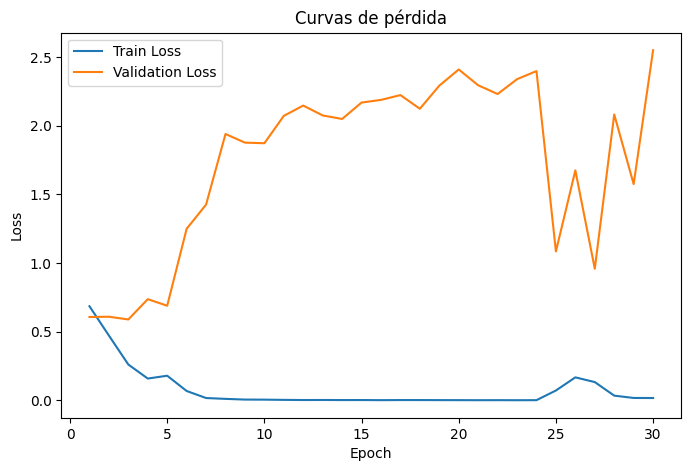

In [19]:
import matplotlib.pyplot as plt


epochs = range(
    1,
    len(history["train_loss"]) + 1
)


plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curvas de pérdida")
plt.legend()
plt.show()

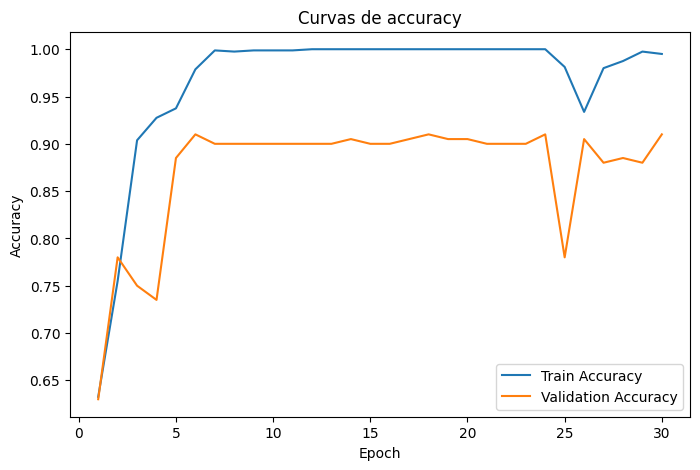

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curvas de accuracy")
plt.legend()
plt.show()

## Almacenamiento de curvas de aprendizaje

Las curvas de aprendizaje permiten analizar la evolución del modelo durante el entrenamiento y observar posibles tendencias de sobreajuste.

In [21]:
# Guardar historial de entrenamiento en un archivo JSON
import json

RESULT_DIR = (
    PROJECT_DIR /
    "results" /
    "classification" /
    "convnext_tiny_baseline"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


with open(
    RESULT_DIR / "history.json",
    "w"
) as f:

    json.dump(
        history,
        f,
        indent=4
    )

In [22]:
RESULT_DIR = (
    PROJECT_DIR /
    "results" /
    "classification" /
    "convnext_tiny_baseline"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

### Guardar Imagenes

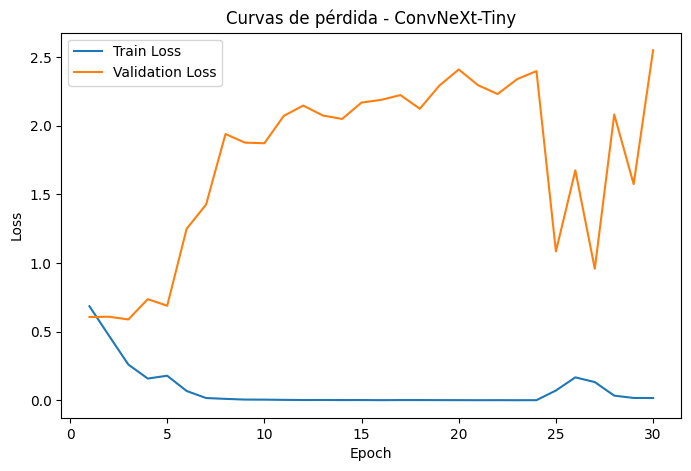

In [23]:
epochs = range(
    1,
    len(history["train_loss"]) + 1
)


plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curvas de pérdida - ConvNeXt-Tiny")

plt.legend()

plt.savefig(
    RESULT_DIR / "loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

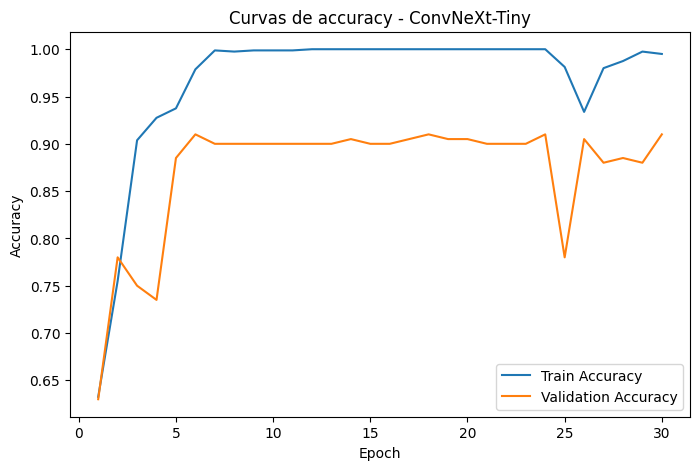

In [24]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curvas de accuracy - ConvNeXt-Tiny")

plt.legend()

plt.savefig(
    RESULT_DIR / "accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()